Now that we have completed inference and extracted the features using both the R(2+1D)-18 and MViT-S model, we will proceed to do the final step, which is to train a linear classifier on the features, to see which model generated more "useful" representations.

In [1]:
# ML Packages
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, roc_curve, confusion_matrix, precision_recall_curve, auc, accuracy_score
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

# script imports & utilities
import sys
ROOT = Path.cwd().parents[0]
sys.path.insert(0, str(ROOT))
from src.utils import seed_everything
from train_probe import train_and_evaluate, paired_bootstrap_auc

seed_everything(42) # We make sure everything is consistent.

[Seed] Global seed set to 42


### 1. Train linear probe and evaluate on metrics

We train a scikit-learn linear classifier on the features, and do some regularization. We note the C-value (inverse strength of regularization) of the model with the best results after regularization.

In [3]:
features_dir = ROOT / "data" / "features"
    
models_to_test = ["r2plus1d", "mvit"]
results = {}

# Train and Evaluate Both Architectures
for model_name in models_to_test:
    results[model_name] = train_and_evaluate(model_name, features_dir)



 Evaluating Pipeline: R2PLUS1D
 Best Val AUC: 0.8291 (C=0.001)
 Locked Val Thresholds -> F1: 0.2825, Sens@90%Spec: 0.2183

 Final Test Set Metrics:
  ROC-AUC:       0.8039
  F1-Score:      0.4099 (at threshold 0.28)
  Accuracy:      0.8692 (at threshold 0.28)
  Target 90%Spec Realized -> Sens: 0.4625, Spec: 0.8926 (at threshold 0.22)

 Evaluating Pipeline: MVIT
 Best Val AUC: 0.8331 (C=0.1)
 Locked Val Thresholds -> F1: 0.3859, Sens@90%Spec: 0.2560

 Final Test Set Metrics:
  ROC-AUC:       0.8280
  F1-Score:      0.4685 (at threshold 0.39)
  Accuracy:      0.8810 (at threshold 0.39)
  Target 90%Spec Realized -> Sens: 0.5188, Spec: 0.9051 (at threshold 0.26)


### 3. Analysis and Visualization

Next, we"ll chart out the results


Saved artifact to: d:\Projects\ecg-stuff\ecg-hfref-classifier\outputs\roc_pr_acc_curve_comparison.png


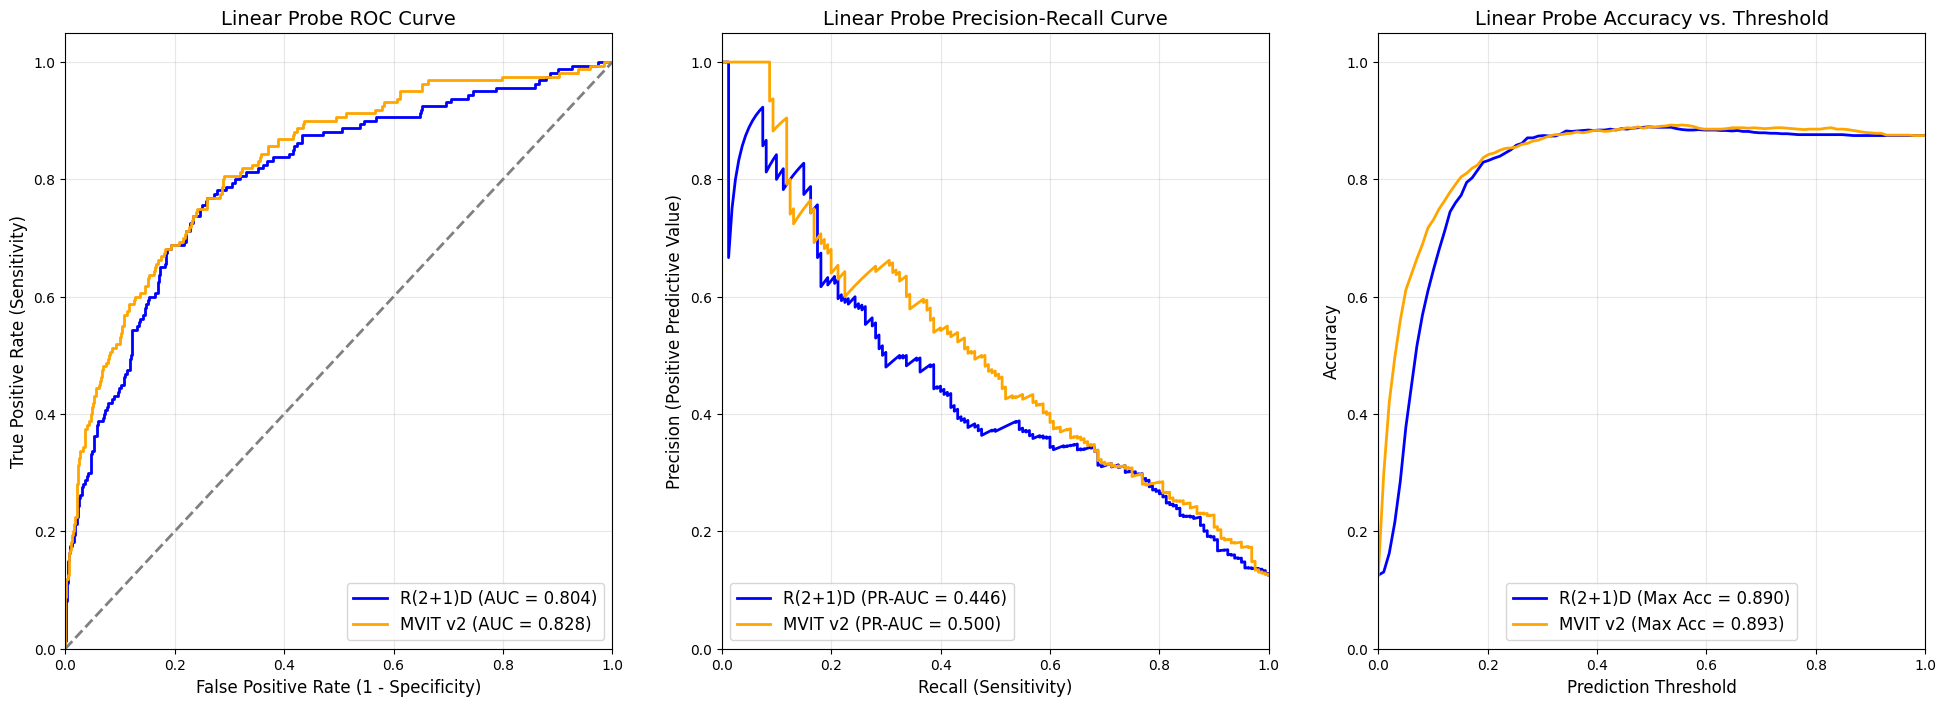

In [4]:
# Generate the "Money" Chart: Overlay ROC, PR Curves, and Accuracy
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

cnn = results["r2plus1d"]
mvit = results["mvit"]

# --- 1. ROC Curve ---
axes[0].plot(cnn["fpr"], cnn["tpr"], color="blue", lw=2, 
                label=f"R(2+1)D (AUC = {cnn["AUC"]:.3f})")
axes[0].plot(mvit["fpr"], mvit["tpr"], color="orange", lw=2, 
                label=f"MVIT v2 (AUC = {mvit["AUC"]:.3f})")
axes[0].plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
axes[0].set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
axes[0].set_title("Linear Probe ROC Curve", fontsize=14)
axes[0].legend(loc="lower right", fontsize=12)
axes[0].grid(alpha=0.3)

# --- 2. Precision-Recall Curve ---
precision_cnn, recall_cnn, _ = precision_recall_curve(cnn["labels"], cnn["probs"])
pr_auc_cnn = auc(recall_cnn, precision_cnn)

precision_mvit, recall_mvit, _ = precision_recall_curve(mvit["labels"], mvit["probs"])
pr_auc_mvit = auc(recall_mvit, precision_mvit)

axes[1].plot(recall_cnn, precision_cnn, color="blue", lw=2, 
                label=f"R(2+1)D (PR-AUC = {pr_auc_cnn:.3f})")
axes[1].plot(recall_mvit, precision_mvit, color="orange", lw=2, 
                label=f"MVIT v2 (PR-AUC = {pr_auc_mvit:.3f})")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("Recall (Sensitivity)", fontsize=12)
axes[1].set_ylabel("Precision (Positive Predictive Value)", fontsize=12)
axes[1].set_title("Linear Probe Precision-Recall Curve", fontsize=14)
axes[1].legend(loc="lower left", fontsize=12)
axes[1].grid(alpha=0.3)

# --- 3. Accuracy vs. Threshold ---
axes[2].plot(cnn["thresholds"], cnn["accuracies"], color="blue", lw=2, 
                label=f"R(2+1)D (Max Acc = {max(cnn["accuracies"]):.3f})")
axes[2].plot(mvit["thresholds"], mvit["accuracies"], color="orange", lw=2, 
                label=f"MVIT v2 (Max Acc = {max(mvit["accuracies"]):.3f})")
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel("Prediction Threshold", fontsize=12)
axes[2].set_ylabel("Accuracy", fontsize=12)
axes[2].set_title("Linear Probe Accuracy vs. Threshold", fontsize=14)
axes[2].legend(loc="lower center", fontsize=12)
axes[2].grid(alpha=0.3)

output_img_path = ROOT / "outputs" / "roc_pr_acc_curve_comparison.png"
output_img_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_img_path, dpi=300, bbox_inches="tight")
print(f"\nSaved artifact to: {output_img_path}")

In [ ]:
# Statistical Comparison (Paired Bootstrap)
print("\n--- The Verdict ---")
    
y_true = mvit["labels"] # Labels are identical for both models
probs_mvit = mvit["probs"]
probs_cnn = cnn["probs"]

mean_diff, ci_lower, ci_upper = paired_bootstrap_auc(y_true, probs_mvit, probs_cnn)
print(f"Mean Difference (MVIT - CNN): {mean_diff:.4f}")
print(f"95% CI of Difference: [{ci_lower:.4f}, {ci_upper:.4f}]")

if ci_lower > 0:
    print("Scenario A: The "Transformer Triumph". MVIT significantly outperformed the CNN.")
elif ci_upper < 0:
    print("Scenario B: The "CNN Stronghold". R(2+1)D significantly outperformed the MVIT.")
else:
    print("Statistical Tie: 0 is within the 95% CI of the difference. Neither architecture strictly dominated.")



--- The Verdict ---
Mean Difference (MVIT - CNN): 0.0243
95% CI of Difference: [-0.0097, 0.0615]
Statistical Tie: 0 is within the 95% CI of the difference. Neither architecture strictly dominated.
